<a href="https://colab.research.google.com/github/zeynepdanis/Neural-Network/blob/main/GRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
#  GRNN Sınıfı
class GRNN:

    def __init__(self, sigma=0.5):

        self.sigma = sigma
        self.X_egitim = None
        self.Y_egitim = None

    # ── EĞİTİM ───────────────────────────────────────────────────────
    def egit(self, X, Y):
        self.X_egitim = np.array(X, dtype=float)
        self.Y_egitim = np.array(Y, dtype=float)
        print(f"GRNN eğitildi: {len(Y)} örnek, σ = {self.sigma}")

    # ── TAHMİN (TEK ÖRNEK) ───────────────────────────────────────────
    def _tahmin_tek(self, x):

        x = np.array(x, dtype=float)

        # Euclid uzaklıkları: D_t = ||x - x^t||
        farklar = self.X_egitim - x                      # (p, n)
        D = np.sqrt((farklar ** 2).sum(axis=1))          # (p,)

        # Gauss aktivasyonu: G_t = exp(-D_t² / 2σ²)
        G = np.exp(-(D ** 2) / (2 * self.sigma ** 2))   # (p,)

        # Toplama katmanı
        WS = np.dot(self.Y_egitim, G)   # Ağırlıklı toplam
        S  = G.sum()                     # Basit toplam

        # Çıkış
        y_hat = WS / S if S > 0 else 0.0
        return y_hat, D, G, WS, S

    # ── TAHMİN ───────────────────────────────────────────────
    def tahmin_et(self, X):
        return np.array([self._tahmin_tek(x)[0] for x in X])

    # ── SINIFLANDIRMA TAHMİNİ ─────────────────────────────────────────
    def siniflandir(self, X, esik=0.5):
        y_hat = self.tahmin_et(X)
        return (y_hat >= esik).astype(int), y_hat

    # ── ADIM ADIM GÖSTER ─────────────────────────────────────────────
    def adim_adim_goster(self, x_test):

        x_test = np.array(x_test, dtype=float)
        y_hat, D, G, WS, S = self._tahmin_tek(x_test)

        print(f"\n{'='*55}")
        print(f"  Test Girdisi: x = {x_test.astype(int).tolist()}")
        print(f"{'='*55}")
        print(f"\n  σ = {self.sigma}")
        print(f"\n  {'t':>4}  {'x^t':>12}  {'y^t':>6}  {'D_t':>8}  {'G_t':>10}")
        print(f"  {'-'*50}")
        for t, (xt, yt, dt, gt) in enumerate(
                zip(self.X_egitim, self.Y_egitim, D, G), 1):
            print(f"  {t:>4}  {str(xt.astype(int).tolist()):>12}  "
                  f"{yt:>6.0f}  {dt:>8.4f}  {gt:>10.4f}")
        print(f"\n  WS = Σ y_t · G_t = {WS:.4f}")
        print(f"  S  = Σ G_t       = {S:.4f}")
        print(f"\n  ŷ  = WS / S     = {y_hat:.4f}")
        print(f"  Sınıf           = {int(y_hat >= 0.5)}")
        print(f"{'='*55}")

In [ ]:

#  Performans Metrikleri
def hesapla_metrikler(y_gercek, y_tahmin):
    y_gercek  = np.array(y_gercek)
    y_tahmin  = np.array(y_tahmin)
    tp = int(((y_tahmin == 1) & (y_gercek == 1)).sum())
    tn = int(((y_tahmin == 0) & (y_gercek == 0)).sum())
    fp = int(((y_tahmin == 1) & (y_gercek == 0)).sum())
    fn = int(((y_tahmin == 0) & (y_gercek == 1)).sum())
    toplam    = tp + tn + fp + fn
    dogruluk  = (tp + tn) / toplam if toplam > 0 else np.nan
    kesinlik  = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    duyarlilik= tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1        = (2 * kesinlik * duyarlilik / (kesinlik + duyarlilik)
                 if not (np.isnan(kesinlik) or np.isnan(duyarlilik)
                         or (kesinlik + duyarlilik) == 0) else np.nan)
    ozgunluk  = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return dict(TP=tp, TN=tn, FP=fp, FN=fn,
                Dogruluk=dogruluk, Kesinlik=kesinlik,
                Duyarlilik=duyarlilik, F1=f1, Ozgunluk=ozgunluk)

def fmt(v):
    if isinstance(v, float) and np.isnan(v): return "—"
    if isinstance(v, float): return f"{v:.4f}"
    return str(v)

In [ ]:
#  XOR Veri Seti
X_egitim = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
], dtype=float)

Y_egitim = np.array([0, 1, 1, 0], dtype=float)


In [ ]:

#  Parametreler
SIGMA = 0.5
ESIK  = 0.5

#  Model Eğitimi
model = GRNN(sigma=SIGMA)
model.egit(X_egitim, Y_egitim)

print("\n-- Adım Adım Hesaplama ──")
model.adim_adim_goster([0, 1])

GRNN eğitildi: 4 örnek, σ = 0.5

-- Adım Adım Hesaplama ──

  Test Girdisi: x = [0, 1]

  σ = 0.5

     t           x^t     y^t       D_t         G_t
  --------------------------------------------------
     1        [0, 0]       0    1.0000      0.1353
     2        [0, 1]       1    0.0000      1.0000
     3        [1, 0]       1    1.4142      0.0183
     4        [1, 1]       0    1.0000      0.1353

  WS = Σ y_t · G_t = 1.0183
  S  = Σ G_t       = 1.2890

  ŷ  = WS / S     = 0.7900
  Sınıf           = 1


In [ ]:

#  Tüm Eğitim Seti Üzerinde Tahmin
y_sinif, y_surekli = model.siniflandir(X_egitim, esik=ESIK)

print("\n── Tahmin Tablosu ──")
print(f"{'#':>3}  {'x1 x2':>8}  {'Hedef':>7}  {'ŷ (sürekli)':>13}  {'Tahmin':>8}  Sonuç")
print("-" * 55)
for i in range(len(X_egitim)):
    grs = f"{int(X_egitim[i,0])} {int(X_egitim[i,1])}"
    ok  = "✓" if y_sinif[i] == int(Y_egitim[i]) else "✗"
    print(f"{i+1:>3}  {grs:>8}  {int(Y_egitim[i]):>7}  "
          f"{y_surekli[i]:>13.4f}  {y_sinif[i]:>8}  {ok}")

acc = (y_sinif == Y_egitim.astype(int)).mean()
print(f"\nGenel Doğruluk: {acc*100:.1f}%  ({int(acc*len(Y_egitim))}/{len(Y_egitim)} örnek)")


── Tahmin Tablosu ──
  #     x1 x2    Hedef    ŷ (sürekli)    Tahmin  Sonuç
-------------------------------------------------------
  1       0 0        0         0.2100         0  ✓
  2       0 1        1         0.7900         1  ✓
  3       1 0        1         0.7900         1  ✓
  4       1 1        0         0.2100         0  ✓

Genel Doğruluk: 100.0%  (4/4 örnek)


In [ ]:
#  Performans Metrikleri
m = hesapla_metrikler(Y_egitim.astype(int), y_sinif)

print("\n── Hata Matrisi ──")
print(f"                 Tahmin:0   Tahmin:1")
print(f"  Gerçek:0  [   {m['TN']:>4}       {m['FP']:>4}   ]")
print(f"  Gerçek:1  [   {m['FN']:>4}       {m['TP']:>4}   ]")

print("\n── Performans Ölçekleri ──")
df = pd.DataFrame({
    "Metrik": ["TP","TN","FP","FN","Doğruluk","Kesinlik","Duyarlılık","F1 Skoru","Özgünlük"],
    "Değer":  [m['TP'], m['TN'], m['FP'], m['FN'],
               fmt(m['Dogruluk']), fmt(m['Kesinlik']),
               fmt(m['Duyarlilik']), fmt(m['F1']), fmt(m['Ozgunluk'])]
})
print(df.to_string(index=False))



── Hata Matrisi ──
                 Tahmin:0   Tahmin:1
  Gerçek:0  [      2          0   ]
  Gerçek:1  [      0          2   ]

── Performans Ölçekleri ──
    Metrik  Değer
        TP      2
        TN      2
        FP      0
        FN      0
  Doğruluk 1.0000
  Kesinlik 1.0000
Duyarlılık 1.0000
  F1 Skoru 1.0000
  Özgünlük 1.0000


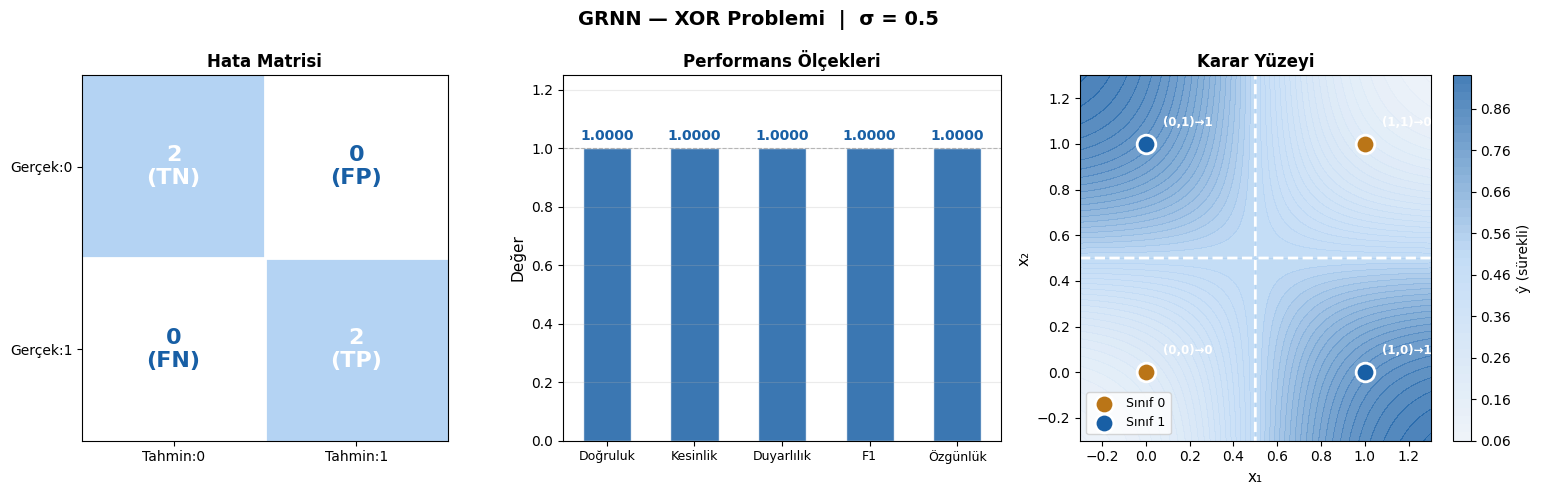


── Sigma Duyarlılık Analizi ──
       σ    ŷ(0,0)    ŷ(0,1)    ŷ(1,0)    ŷ(1,1)    Doğruluk
  ----------------------------------------------------------
GRNN eğitildi: 4 örnek, σ = 0.1
     0.1    0.0000    1.0000    1.0000    0.0000      100.0%
GRNN eğitildi: 4 örnek, σ = 0.3
     0.3    0.0077    0.9923    0.9923    0.0077      100.0%
GRNN eğitildi: 4 örnek, σ = 0.5
     0.5    0.2100    0.7900    0.7900    0.2100      100.0%
GRNN eğitildi: 4 örnek, σ = 0.7
     0.7    0.3895    0.6105    0.6105    0.3895      100.0%
GRNN eğitildi: 4 örnek, σ = 1.0
     1.0    0.4700    0.5300    0.5300    0.4700      100.0%
GRNN eğitildi: 4 örnek, σ = 2.0
     2.0    0.4981    0.5019    0.5019    0.4981      100.0%
GRNN eğitildi: 4 örnek, σ = 5.0
     5.0    0.5000    0.5000    0.5000    0.5000      100.0%


In [ ]:

#  Grafikler
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'GRNN — XOR Problemi  |  σ = {SIGMA}',
             fontsize=14, fontweight='bold')

MAVI   = '#185FA5'
TURUNCU= '#BA7517'

# ── 1) Hata Matrisi ──────────────────────────────────────────────────────────
ax = axes[0]
cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
cmap = LinearSegmentedColormap.from_list('bl', ['#FFFFFF', '#B5D4F4', MAVI])
ax.imshow(cm, cmap=cmap, vmin=0, vmax=max(4,1))
etiketler = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        renk = 'white' if cm[i,j] >= 2 else MAVI
        ax.text(j, i, f"{cm[i,j]}\n({etiketler[i][j]})",
                ha='center', va='center', fontsize=16,
                fontweight='bold', color=renk)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Tahmin:0','Tahmin:1'], fontsize=10)
ax.set_yticklabels(['Gerçek:0','Gerçek:1'], fontsize=10)
ax.set_title('Hata Matrisi', fontsize=12, fontweight='bold')
ax.set_xticks([0.5], minor=True); ax.set_yticks([0.5], minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', length=0)

# ── 2) Performans Bar Grafiği ─────────────────────────────────────────────────
ax = axes[1]
metrik_adlar = ['Doğruluk', 'Kesinlik', 'Duyarlılık', 'F1', 'Özgünlük']
metrik_vals  = [m['Dogruluk'], m['Kesinlik'], m['Duyarlilik'], m['F1'], m['Ozgunluk']]
renkler = [MAVI if not np.isnan(v) else '#CCCCCC' for v in metrik_vals]
vals_plot = [v if not np.isnan(v) else 0 for v in metrik_vals]
bars = ax.bar(metrik_adlar, vals_plot, color=renkler, alpha=0.85, edgecolor='white', width=0.55)
for bar, v in zip(bars, metrik_vals):
    label = fmt(v) if not np.isnan(v) else "—"
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02, label,
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=MAVI)
ax.set_ylim(0, 1.25)
ax.set_ylabel('Değer', fontsize=11)
ax.set_title('Performans Ölçekleri', fontsize=12, fontweight='bold')
ax.axhline(1.0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.grid(axis='y', alpha=0.25)
ax.tick_params(axis='x', labelsize=9)

# ── 3) Karar Yüzeyi ──────────────────────────────────────────────────────────
ax = axes[2]
res = 200
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, res), np.linspace(-0.3, 1.3, res))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = model.tahmin_et(grid).reshape(res, res)

cmap2 = LinearSegmentedColormap.from_list('karar', ['#EBF1F8', '#B5D4F4', MAVI])
cf = ax.contourf(xx, yy, zz, levels=50, cmap=cmap2, alpha=0.8)
ax.contour(xx, yy, zz, levels=[0.5], colors='white', linewidths=2, linestyles='--')
plt.colorbar(cf, ax=ax, label='ŷ (sürekli)')

sinif_renk = {0: TURUNCU, 1: MAVI}
etiket_yazildi = {0: False, 1: False}
for i, (xi, yi) in enumerate(zip(X_egitim, Y_egitim)):
    c = int(yi)
    lbl = f'Sınıf {c}' if not etiket_yazildi[c] else None
    ax.scatter(xi[0], xi[1], s=180, color=sinif_renk[c],
               edgecolors='white', linewidths=2, zorder=5, label=lbl)
    ax.annotate(f'({int(xi[0])},{int(xi[1])})→{c}',
                xy=(xi[0], xi[1]), xytext=(xi[0]+0.08, xi[1]+0.08),
                fontsize=8.5, color='white', fontweight='bold')
    etiket_yazildi[c] = True

ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('x₁', fontsize=11); ax.set_ylabel('x₂', fontsize=11)
ax.set_title('Karar Yüzeyi', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
#  Sigma Duyarlılık Analizi
# ─────────────────────────────────────────
print("\n── Sigma Duyarlılık Analizi ──")
sigma_degerler = [0.1, 0.3, 0.5, 0.7, 1.0, 2.0, 5.0]
print(f"  {'σ':>6}  {'ŷ(0,0)':>8}  {'ŷ(0,1)':>8}  {'ŷ(1,0)':>8}  {'ŷ(1,1)':>8}  {'Doğruluk':>10}")
print("  " + "-"*58)
for s in sigma_degerler:
    m_tmp = GRNN(sigma=s)
    m_tmp.egit(X_egitim, Y_egitim)
    y_s, y_s_cont = m_tmp.siniflandir(X_egitim)
    acc_s = (y_s == Y_egitim.astype(int)).mean()
    print(f"  {s:>6.1f}  {y_s_cont[0]:>8.4f}  {y_s_cont[1]:>8.4f}  "
          f"{y_s_cont[2]:>8.4f}  {y_s_cont[3]:>8.4f}  {acc_s*100:>9.1f}%")